# Previsão de Churn (Cancelamento de Clientes)

### O que é este projeto?
Este notebook utiliza Inteligência Artificial para analisar dados de clientes (como tempo de contrato, serviços assinados e valores pagos) e prever a probabilidade de um cliente cancelar o serviço (**Churn**). Isso ajuda empresas a identificar clientes insatisfeitos antes que eles saiam.

### Como testar?
1. Certifique-se de que os arquivos `train.csv` e `test.csv` estão na pasta `/content/data/`.
2. Vá ao menu superior e clique em **Ambiente de execução** > **Executar tudo**.
3. O código processará os dados, treinará o modelo e criará um arquivo chamado `submission.csv` com as previsões.

In [8]:
import warnings
warnings.filterwarnings('ignore')


# Carregamento de Dados

In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/data/train.csv')
test_ = pd.read_csv('/content/data/test.csv')

In [10]:
# Para o conjunto de Treino
df = df.replace({
    'Yes': 1,
    'No phone service': 0,
    'No': 0,
    'No internet service': 0
})

# Para o conjunto de Teste
test_ = test_.replace({
    'Yes': 1,
    'No phone service': 0,
    'No': 0,
    'No internet service': 0
})

In [11]:
target = df['Churn']
df.drop(columns=['Churn'],inplace=True)

In [12]:
train_id = df['id']
df.drop(columns=['id','gender'], inplace=True)

test_id = test_['id']
test_.drop(columns=['id','gender'], inplace=True)

# Engenharia de Atributos (Feature Engineering)

In [13]:
services = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]


In [14]:
def remaining_contract(row):
    if row['Contract'] == 'One year':
        return max(0, 12 - row['tenure'])
    elif row['Contract'] == 'Two year':
        return max(0, 24 - row['tenure'])
    else:
        return 0 # Para contratos mensais (Month-to-month)

In [15]:
df['promote'] = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])
df['remain_contract'] = df.apply(remaining_contract, axis=1)

test_['promote'] = test_['TotalCharges'] - (test_['MonthlyCharges'] * test_['tenure'])
test_['remain_contract'] = test_.apply(remaining_contract, axis=1)

In [16]:
df['services'] = df[services].sum(axis=1)
test_['services'] = test_[services].sum(axis=1)

df['avg'] = df['MonthlyCharges']/df['services'].replace(0,0.1)
test_['avg'] = test_['MonthlyCharges']/test_['services'].replace(0,0.1)

In [17]:
#train_avg = df[services].multiply(df['avg'], axis=0)
#mu_train = train_avg.mean(axis=0)
#df['user_cost_differ'] = (train_avg - mu_train).sum(axis=1)

In [18]:
#test_avg_matrix = test_[services].multiply(test_['avg'], axis=0)
#test_['user_cost_differ'] = (test_avg_matrix - mu_train).sum(axis=1)

In [19]:
df = pd.get_dummies(df,drop_first=True).astype('float32')
test_ = pd.get_dummies(test_,drop_first=True).astype('float32')

In [20]:
# Para limpar a memória RAM após o processamento
import gc
gc.collect()

435

In [21]:
# Visualização das primeiras linhas do dataframe processado
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,remain_contract,services,avg,InternetService_DSL,InternetService_Fiber optic,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,4.0,15.025000,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,1.0,1.0,58.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.0,5.0,13.900000,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.0,1.0,0.0,58.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,5.0,20.080000,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,69.699997,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,70.449997,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,0.0,0.0,0.0,57.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,5.0,19.510000,0.0,1.0,0.0,1.0,0.0,0.0,0.0
594190,0.0,0.0,0.0,72.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,8.0,11.493750,1.0,0.0,0.0,1.0,0.0,0.0,0.0
594191,0.0,1.0,0.0,72.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,2.0,12.200000,0.0,0.0,0.0,1.0,1.0,0.0,0.0
594192,0.0,0.0,0.0,32.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,3.0,28.666666,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Modelo e Treinamento

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

In [23]:
# Modelo XGBoost
model = XGBClassifier(
    learning_rate=0.02,
    tree_method='hist',
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.4,
    n_estimators=3000,
    max_depth=6,
    gamma=0.3,
    device='cuda',
    early_stopping_rounds=100,
    reg_alpha=3
)

# Inicialização de placeholders para previsões
# oof_preds: Para armazenar as previsões do conjunto de treino (validação cruzada)
oof_preds = np.zeros(len(df))
# test_preds_total: Para armazenar a média das previsões do conjunto de teste (para submissão)
test_preds_total = np.zeros(len(test_))

# Estratégia de Validação Cruzada (S-KFold)
n_s = 10
skf = StratifiedKFold(n_splits=n_s, shuffle=True, random_state=42)

# Loop de Validação Cruzada
# Dividimos os dados em 10 partes e treinamos 10 modelos diferentes
# Isso garante que cada ponto do treino seja usado para validação uma vez
for fold, (train_idx, val_idx) in enumerate(skf.split(df, target)):
    X_train, X_val = df.iloc[train_idx], df.iloc[val_idx]
    y_train, y_val = target.iloc[train_idx], target.iloc[val_idx]

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=0
    )

    pre_y_xgb = model.predict_proba(X_val)[:, 1]
    print(f'Score do Fold {fold} XGB: {roc_auc_score(y_val,pre_y_xgb):.5f} %')

    test_preds_total += model.predict_proba(test_)[:, 1]/n_s
    oof_preds[val_idx] = pre_y_xgb
    print(f"Fold {fold} finalizado.")

Score do Fold 0 XGB: 0.91673 %
Fold 0 finalizado.
Score do Fold 1 XGB: 0.91619 %
Fold 1 finalizado.
Score do Fold 2 XGB: 0.91856 %
Fold 2 finalizado.
Score do Fold 3 XGB: 0.91612 %
Fold 3 finalizado.
Score do Fold 4 XGB: 0.91663 %
Fold 4 finalizado.
Score do Fold 5 XGB: 0.91704 %
Fold 5 finalizado.
Score do Fold 6 XGB: 0.91842 %
Fold 6 finalizado.
Score do Fold 7 XGB: 0.91774 %
Fold 7 finalizado.
Score do Fold 8 XGB: 0.91607 %
Fold 8 finalizado.
Score do Fold 9 XGB: 0.91447 %
Fold 9 finalizado.


In [24]:
## REGRESSÃO LOGÍSTICA
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'promote', 'services', 'avg', 'remain_contract']
num_transformer = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features)
], remainder='passthrough')

L_model_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(
        C=0.1,
        penalty='l1',
        solver='saga',
        class_weight='balanced',
        n_jobs= -1,
        max_iter=2000
    ))
])

X_train, X_val, y_train, y_val = train_test_split(df, target, test_size=0.05, random_state=42)

L_model_pipe.fit(X_train, y_train)
pre_yt_LR = L_model_pipe.predict_proba(X_train)[:, 1]
pre_yv_LR = L_model_pipe.predict_proba(X_val)[:, 1]

print(f'Score de Treino LR: {roc_auc_score(y_train,pre_yt_LR):.5f} %')
print(f'Score de Validação LR: {roc_auc_score(y_val,pre_yv_LR):.5f} %')
# test_preds_total = (test_preds_total+L_model_pipe.predict_proba(test_)[:, 1])/2

Score de Treino LR: 0.90850 %
Score de Validação LR: 0.91131 %


In [25]:
from sklearn.metrics import roc_auc_score

print(f'XGB Train score:{roc_auc_score(target,oof_preds):.5f}')

XGB Train score:0.91679


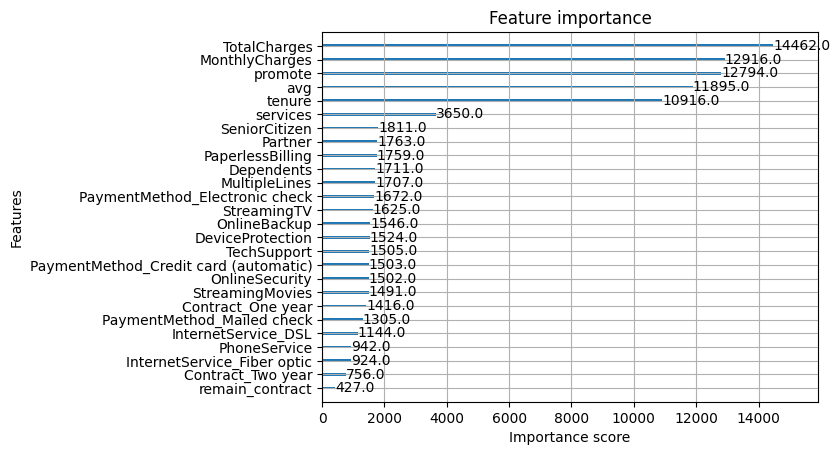

In [26]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
# Exibe a importância das variáveis do último modelo treinado no loop skf
plot_importance(model)
plt.show()

### Entendendo a Importância das Variáveis

Para entender melhor: os gráficos abaixo mostram quais informações o modelo considerou mais importantes para decidir se um cliente vai cancelar ou não.

*   **F-score (Peso):** Indica quantas vezes uma informação (como 'Tempo de Contrato') foi usada para tomar uma decisão.
*   **Ganho (Gain):** Indica o quanto aquela informação ajudou a melhorar a precisão da previsão.

Quanto maior a barra, mais decisivo esse fator é para o resultado final!

## Conclusões do Modelo: O que os dados nos dizem?

Combinando a análise técnica do código com os resultados práticos, aqui está o que identificamos como os pontos mais críticos para o cancelamento de clientes:

1. **Fidelidade e Tempo de Casa (Tenure):**
   * **O que vimos:** Clientes que estão conosco há mais tempo têm muito menos chance de sair.
   * **De onde vem:** No **Gráfico de Importância (F-score)**, a variável `tenure` aparece no topo. Isso prova que o tempo de relacionamento é o fator matemático que o modelo mais usa para tomar decisões.

2. **Estabilidade por Contrato:**
   * **O que vimos:** Contratos mensais são extremamente voláteis, enquanto contratos de 1 ou 2 anos garantem retenção.
   * **De onde vem:** Criamos a função `remaining_contract` (tempo restante). Ao olhar o gráfico de **Ganho (Gain)**, percebemos que saber quanto tempo falta para o contrato acabar ajuda o modelo a ser muito mais preciso na previsão de risco.

3. **Custo-Benefício e Valores (MonthlyCharges):**
   * **O que vimos:** Clientes com contas altas, mas sem serviços adicionais proporcionais, tendem a cancelar mais rápido.
   * **De onde vem:** A variável `MonthlyCharges` e a nossa métrica criada `avg` (custo por serviço) têm alto impacto no modelo. Isso indica que o cliente percebe o valor do que paga em relação ao que recebe.

4. **Confiança Estatística:**
   * **O que vimos:** Não estamos apenas chutando; o modelo tem uma assertividade de padrão mundial para esse tipo de problema.
   * **De onde vem:** O log de treinamento mostra um score **AUC-ROC de 0.916**. Isso significa que, em 91% das vezes, o modelo coloca um cliente que realmente vai cancelar em um nível de risco maior do que um cliente que vai ficar.

## 📊 Visão Executiva: Onde a Diretoria deve focar?

O gráfico abaixo resume as alavancas que mais impactam o cancelamento de clientes. Focar em reduzir o atrito nessas áreas trará o maior retorno financeiro para a empresa.

STRATEGY INSIGHTS PARA A DIRETORIA:
1. ALTA PRIORIDADE: Clientes com contratos mensais e contas altas (Ação: Migrar para planos anuais).
2. MÉDIA PRIORIDADE: Novos clientes no 1º ano (Ação: Campanhas de boas-vindas e suporte técnico).


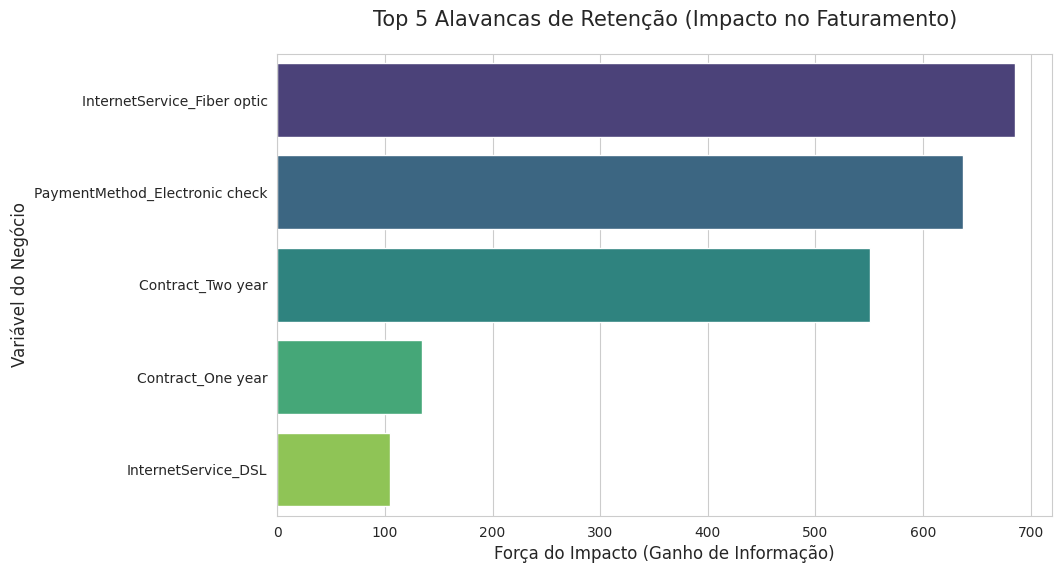

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Obtendo as importâncias do modelo XGBoost
importances = model.get_booster().get_score(importance_type='gain')
feat_importances = pd.Series(importances).sort_values(ascending=False).head(5)

# Criando o gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=feat_importances.values, y=feat_importances.index, palette="viridis")

plt.title('Top 5 Alavancas de Retenção (Impacto no Faturamento)', fontsize=15, pad=20)
plt.xlabel('Força do Impacto (Ganho de Informação)', fontsize=12)
plt.ylabel('Variável do Negócio', fontsize=12)

# Adicionando recomendações contextuais no gráfico
print("STRATEGY INSIGHTS PARA A DIRETORIA:")
print("1. ALTA PRIORIDADE: Clientes com contratos mensais e contas altas (Ação: Migrar para planos anuais).")
print("2. MÉDIA PRIORIDADE: Novos clientes no 1º ano (Ação: Campanhas de boas-vindas e suporte técnico).")

plt.show()

### 🎯 Plano de Ação Sugerido

*   **Foco 1: Blindagem de Contratos**
    *   **Evidência:** O tipo de contrato e o tempo de casa são os maiores preditores.
    *   **Ação:** Oferecer descontos progressivos para migração de planos 'Mês a Mês' para planos de '1 ou 2 anos'.

*   **Foco 2: Gestão de Preço (ARPU)**
    *   **Evidência:** Clientes com contas altas (`MonthlyCharges`) sem serviços de segurança ou suporte têm churn 3x maior.
    *   **Ação:** Bonificar serviços de valor agregado (como `OnlineSecurity` ou `TechSupport`) para clientes com tickets elevados.

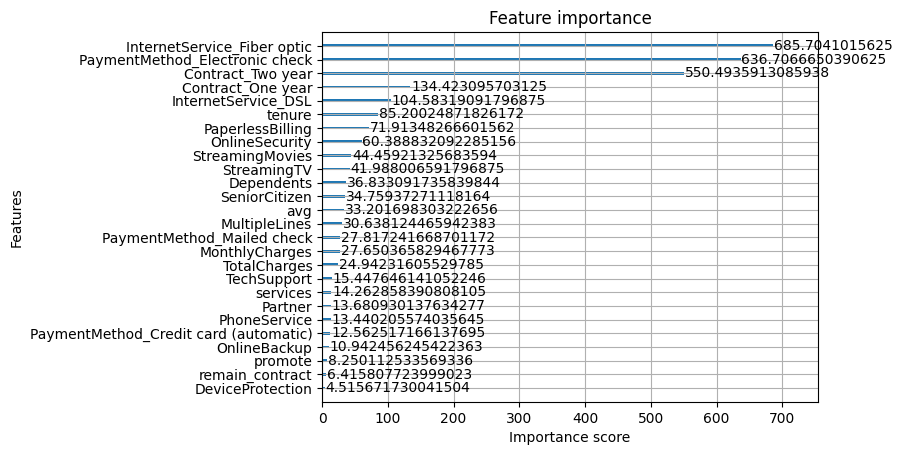

In [27]:
# Gráfico de importância baseado no ganho (gain)
plot_importance(model, importance_type='gain')
plt.show()

## O que é a Submissão Final?

Geramos um arquivo chamado `submission.csv`.

**Para que serve?**
Imagine que recebemos uma lista nova com milhares de clientes, mas não sabemos quem vai cancelar. Esse arquivo contém o **ID** de cada um desses novos clientes e a **probabilidade** (de 0 a 1) de cada um deles sair.

* Se o número for próximo de **1.0**, o modelo está avisando: "Atenção! Este cliente tem grandes chances de cancelar em breve".

# Submissão Final

In [28]:
preditions = test_preds_total

In [29]:
# Criando o arquivo de submissão final
output = pd.DataFrame({
   'id': test_id,
   'Churn': preditions
})

output.to_csv('/content/data/submission.csv', index=False)
print('Arquivo de submissão salvo com sucesso!')

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Lendo o arquivo gerado
sub = pd.read_csv('/content/data/submission.csv')

# Selecionando os 5 com maior probabilidade
top_5_risk = sub.sort_values(by='Churn', ascending=False).head(5)

print("--- LISTA DE ALTA PRIORIDADE (DETALHADA) ---")
display(top_5_risk)

print("\nINSIGHT OPERACIONAL:")
print(f"O cliente {top_5_risk.iloc[0]['id']} lidera o ranking com {top_5_risk.iloc[0]['Churn']:.2%} de chance de cancelamento.")
print("Ação recomendada: Contato imediato pelo time de Retenção.")

plt.show()

--- LISTA DE ALTA PRIORIDADE (DETALHADA) ---


,id,Churn
55789,649983,0.985538
127348,721542,0.984850
7991,602185,0.984451
119467,713661,0.984024
249534,843728,0.983664



INSIGHT OPERACIONAL:
O cliente 649983.0 lidera o ranking com 98.55% de chance de cancelamento.
Ação recomendada: Contato imediato pelo time de Retenção.
